# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/melikekaya01/flyrank-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Prioritizing Content for Human Review Using Search and Engagement Signals

## Abstract

FlyRank’s practical content problem is deciding which pages should be reviewed first when editors and SEO reviewers cannot inspect every content record.

Using 30,000 anonymized content-level records, this project compared an interpretable CTR-based rule with Logistic Regression and Random Forest. Precision@50 was selected as the primary metric because the intended output is a short human-review queue rather than an automated content-editing system.

The fixed-rule baseline achieved a Precision@50 of 0.68, compared with 0.64 for Logistic Regression and 0.58 for Random Forest. Although Random Forest achieved the highest ROC-AUC at 0.6111, it did not produce the strongest first 50 recommendations.

The results support using the transparent fixed-rule baseline as the initial content-review queue. However, the evaluation was performed offline and does not prove that editing the recommended pages will improve business performance.


## 1. Question

*The research question and the decision it supports.*

## Introduction

FlyRank content teams may have more pages to review than editors and SEO specialists can inspect manually. Therefore, the main problem is deciding which content records should be reviewed first.

This project treats the task as a ranking and decision-support problem. The system does not automatically edit, remove, or publish content. Instead, it produces a short and explainable queue for human review.

The study compares a transparent fixed-rule CTR baseline with Logistic Regression and Random Forest. The goal is to determine whether a more complex machine learning model improves the first 50 recommendations that a reviewer would realistically inspect.

### Research Question

Can historical search visibility, click-through, engagement, and content-freshness signals help FlyRank identify which content records should be reviewed first?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the public-safe, anonymized dataset provided through the FlyRank ML Internship. The internship release was derived from approximately 79 million rows of production search and analytics data. For the modeling and ranking stages, I used the prepared `content_refresh_anonymized.csv` analysis table, which contains 30,000 content-level records and 44 columns.

The underlying data combines anonymized search-performance and web-analytics signals. Relevant fields include impressions, clicks, click-through rate, average search position, engagement measures, content freshness, and recent trend information. Client and content identifiers are hashed, and the analysis does not expose client names, page URLs, private search queries, or other identifying information.

For the forward-looking data-contract experiment, March 2026 was used as the feature window and April 2026 as the outcome window. The later modeling dataset uses prepared historical aggregates such as 30-day and 90-day performance measures supplied in the internship release.

The following fields were excluded from model features:

- Client and content identifiers, because they identify or group records rather than describe transferable behavior.
- Current- and previous-period values directly used to construct the target.
- `trend_direction` and `trend_pct`, because they directly reveal or closely approximate the label.
- Client names, URLs, search queries, and other private fields.
- Columns unavailable at the time a real review decision would be made.

These exclusions reduce identification risk, prevent target leakage, and keep the final research artifact safe for public deployment.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

### Assumptions

The project assumes that historical search visibility, click-through performance, engagement, content freshness, and recent behavior contain useful signals for prioritizing content for human review.

The analysis does not assume that a high score proves that an edit will improve performance. It only estimates which records may be more useful to inspect first.

### Label Definition

The modeling target is a binary decline indicator created from future-period performance. A positive label represents a content record that declined in the defined outcome period. Features were restricted to information available before that outcome period.

### Features

The final modeling frame included public-safe numeric and categorical variables related to:

- Search impressions and clicks
- Click-through rate
- Average search position
- Engagement and session behavior
- Content age and time since last update
- Historical performance aggregates
- Public-safe content and client tiers

Identifiers and fields that directly defined or closely reproduced the target were excluded.

### Baseline

The Week 4 fixed-rule baseline ranks records using an action score based on visible search demand, search position, weak click-through performance, weak engagement, and related opportunity signals.

Each selected record also receives a reason code and a recommended human-review action. The baseline is intentionally simple and interpretable.

### Models

Two supervised classification models were compared with the fixed-rule baseline:

1. Logistic Regression
2. Random Forest

The models produced probability scores that were used to rank test records from highest to lowest predicted risk.

### Validation Design

The data was split by client rather than by random row. The training set contained 23,837 records from 25 clients, while the test set contained 6,163 records from 7 different clients.

There was no client overlap between the training and test sets. This grouped holdout design provides a stricter test of whether the ranking approach generalizes to unseen clients.

### Evaluation Metrics

Precision@50 was selected as the primary operational metric because reviewers can inspect only a small number of records at one time.

The analysis also reports:

- Precision@20
- Recall@50
- Average Precision
- ROC-AUC
- Test-set base rate

These metrics describe different aspects of ranking performance and should not be treated as interchangeable.

### Leakage Checks

Potential leakage and identification risks were reviewed before training. Identifier fields, direct label sources, label-construction proxies, and fields unavailable at decision time were excluded.

The validation audit also confirmed that client groups did not overlap between the training and test sets.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

All methods were evaluated on the same grouped test split containing 6,163 records from 7 unseen clients. The positive-class base rate in the test set was 0.511.

| Method | Precision@20 | Precision@50 | Recall@50 | Average Precision | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Week 4 CTR baseline | 0.75 | 0.68 | 0.0108 | 0.5223 | 0.5202 |
| Logistic Regression | 0.70 | 0.64 | 0.0102 | 0.5691 | 0.5777 |
| Random Forest | 0.60 | 0.58 | 0.0092 | 0.5898 | 0.6111 |

### Main Finding

The Week 4 CTR baseline achieved the strongest operational result, with a Precision@50 of 0.68. This means that 34 of the first 50 baseline recommendations were positive cases on the held-out test set.

Logistic Regression achieved a Precision@50 of 0.64, while Random Forest achieved 0.58. Therefore, neither machine learning model improved the primary top-of-queue metric over the fixed-rule baseline.

Random Forest achieved the highest ROC-AUC, at 0.6111. However, ROC-AUC measures discrimination across the full test set, while Precision@50 focuses on the small group of records that reviewers would inspect first.

Because the main operational objective is to place useful candidates near the top of a limited human-review queue, the fixed-rule baseline was retained as the preferred ranking approach.

### Interpretation

The result does not show that machine learning is generally ineffective. It shows that, for this dataset, split, label definition, and review capacity, the more complex models did not outperform the interpretable baseline on the primary operational metric.

The output should be treated as a prioritization aid rather than proof that reviewing or editing a recommended record will improve business performance.

## 5. Limitations

*What this work cannot claim.*

## Limitations and Honest Framing

This study is an offline evaluation of ranking methods. It does not measure what happens after reviewers act on the recommendations, and it does not prove that editing a selected content record will improve traffic, engagement, or business outcomes.

The test-set positive rate was 0.511. Because the base rate is relatively high, top-of-queue precision should be interpreted together with the base rate and the other evaluation metrics.

The label is a proxy for future decline rather than a direct measure of whether a page should be refreshed. A positive label may reflect seasonality, changes in search demand, competition, technical issues, or other factors not represented in the dataset.

The dataset contains aggregated historical signals. It does not fully capture search intent, SERP layout, advertising activity, algorithm updates, content quality, competitor actions, or the cost and expected value of an intervention.

The fixed-rule thresholds and score weights were manually designed from observed patterns. They may require recalibration for a different time period, client group, market, or review capacity.

The client-grouped holdout provides a stronger validation design than a random row split, but the results still come from one prepared dataset and one test split.

The machine learning models were not extensively tuned, and the analysis does not establish that Logistic Regression or Random Forest are the best possible model families for this task.

Finally, the ranked queue supports human review. It should not automatically edit, remove, or publish content without additional investigation and editorial judgment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The final output is a ranked action playbook for human review. Records near the top of the queue combine stronger evidence of visibility, weak click-through or engagement performance, and a clearer opportunity for investigation.

### Priority 1 — Review title and meta information

Use this action for pages that already receive meaningful search visibility but attract relatively few clicks.

Recommended checks:

- Compare the page title with the dominant search intent.
- Review the meta description for clarity and relevance.
- Check whether the search snippet communicates a specific benefit.
- Inspect whether the page competes with stronger SERP features or advertisements.

Expected use: editorial and SEO review, not automatic rewriting.

### Priority 2 — Refresh visible but aging content

Use this action for older pages that continue to receive impressions but show weak or declining performance.

Recommended checks:

- Verify whether facts, dates, examples, and screenshots remain current.
- Compare the page with newer competing content.
- Update sections that no longer answer the likely user need.
- Preserve useful sections rather than replacing the entire page without evidence.

Expected use: targeted content refresh after manual inspection.

### Priority 3 — Investigate engagement weakness

Use this action for records with visibility or clicks but weak downstream engagement.

Recommended checks:

- Confirm that the page satisfies the promise made in the search result.
- Review page structure, readability, internal links, and calls to action.
- Check for slow loading, layout issues, or distracting elements.
- Distinguish content-quality problems from differences in user intent.

Expected use: diagnostic review before making changes.

### Priority 4 — Reassess low-confidence candidates

Records with weaker evidence, limited impressions, or borderline scores should remain lower in the queue.

Recommended checks:

- Gather more observations before acting.
- Avoid prioritizing unstable percentages from very small volumes.
- Review seasonal or campaign-related context.
- Compare the cost of intervention with the expected value.

Expected use: monitoring or secondary review.

### Operating Recommendation

Use the fixed-rule CTR baseline as the initial queue generator because it achieved the strongest Precision@50 on the held-out client split and remains easy to explain.

Review the top 50 records manually, document the action taken, and collect post-review outcomes. Those outcomes can later support threshold recalibration, improved labels, and a more reliable comparison between the baseline and future machine learning models.

The queue should be refreshed periodically rather than treated as a permanent ranking.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Method": [
        "Week 4 CTR baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [0.75, 0.70, 0.60],
    "Precision@50": [0.68, 0.64, 0.58],
    "Recall@50": [0.0108, 0.0102, 0.0092],
    "Average Precision": [0.5223, 0.5691, 0.5898],
    "ROC-AUC": [0.5202, 0.5777, 0.6111]
})

test_base_rate = 0.511

display(results.round(4))
print(f"Test-set base rate: {test_base_rate:.3f}")

,Method,Precision@20,Precision@50,Recall@50,Average Precision,ROC-AUC
0,Week 4 CTR baseline,0.75,0.68,0.0108,0.5223,0.5202
1,Logistic Regression,0.70,0.64,0.0102,0.5691,0.5777
2,Random Forest,0.60,0.58,0.0092,0.5898,0.6111


Test-set base rate: 0.511


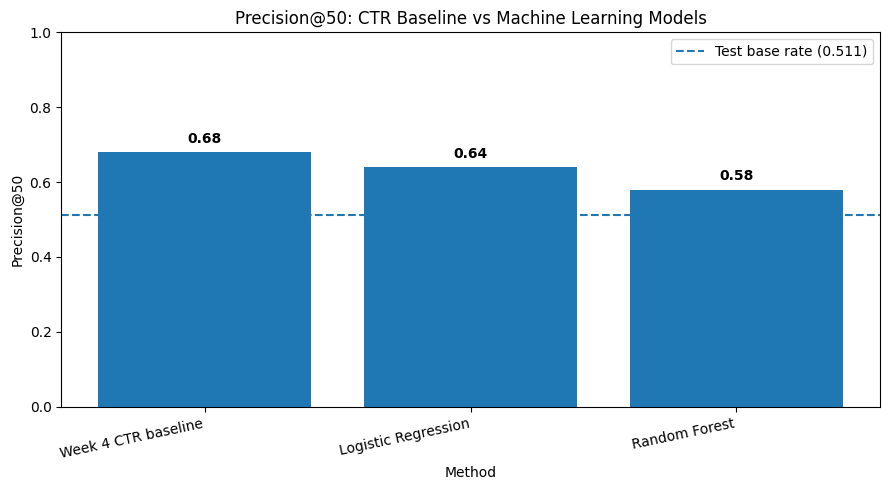

In [ ]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    results["Method"],
    results["Precision@50"]
)

plt.axhline(
    test_base_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Test base rate ({test_base_rate:.3f})"
)

plt.title("Precision@50: CTR Baseline vs Machine Learning Models")
plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.ylim(0, 1.0)
plt.xticks(rotation=12, ha="right")
plt.legend()

for bar, value in zip(bars, results["Precision@50"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "precision_at_50_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Reproducibility

The analysis can be inspected and rerun through the public project repository and its weekly notebooks.

- Repository: https://github.com/melikekaya01/flyrank-ml
- Data contract: `work/notebooks/w03_data_contract.ipynb`
- Fixed-rule baseline: `work/notebooks/w04_baseline_score.ipynb`
- Model comparison: `work/notebooks/w05_model.ipynb`
- Validation audit: `work/notebooks/w06_validation_audit.ipynb`
- Action playbook: `work/notebooks/w07_action_playbook.ipynb`
- Capstone notebook: `work/notebooks/capstone.ipynb`

Random seeds, grouped validation decisions, excluded leakage fields, evaluation metrics, and final recommendation logic are documented in the notebooks.

## Acknowledgments and Data Credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

The project was completed as part of the FlyRank ML Internship. The dataset and project structure were supplied for educational research and portfolio development. All published outputs use anonymized, public-safe information.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# Week 8 Showcase — 5-Minute Demo Outline

## Question

Can historical search visibility, click-through, engagement, and content freshness signals help FlyRank decide which content records should be reviewed first?

## Method

I used 30,000 anonymized content-level records and compared three approaches:

* A fixed-rule CTR baseline
* Logistic Regression
* Random Forest

The data was separated with a client-grouped holdout so that the test clients were different from the training clients.

## One Chart

Show the Precision@50 comparison chart.

* Fixed-rule CTR baseline: 0.68
* Logistic Regression: 0.64
* Random Forest: 0.58

## Honest Result

The fixed-rule baseline produced the strongest first 50 recommendations.

Random Forest had the highest ROC-AUC, but it did not perform best for the small review queue. This shows that a more complex model is not automatically more useful for the business objective.

The evaluation was offline, so the results do not prove that reviewing or editing the recommended content will improve business performance.

## Recommendation

Use the interpretable fixed-rule baseline as the first content-review queue.

The top recommendations should be checked by a human reviewer, and the actions and outcomes should be recorded for future model improvements.


# Shareable Cuts

## Short Social Post

I built a content-review prioritization workflow using 30,000 anonymized FlyRank content records.

I compared a fixed-rule CTR baseline with Logistic Regression and Random Forest. I used a client-grouped holdout and selected Precision@50 as the main metric because the goal was to create a short queue for human review.

The fixed-rule baseline achieved the best Precision@50 at 0.68. This showed that a simple and interpretable method can be more useful than a complex model when it better matches the real business objective.

#MachineLearning #DataScience #SEO #FlyRank

## Employer-Facing Summary

I built an interpretable system that ranks content records for editorial and SEO review. I used 30,000 anonymized content-level records and compared a fixed-rule CTR baseline with Logistic Regression and Random Forest. The fixed-rule baseline achieved the strongest Precision@50 at 0.68, showing that a simple method can be more useful than a complex model for a limited human-review queue.
